In [8]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from rasterio.plot import plotting_extent

def plot_traversal_map(raster_path: str, title: str, cmap_name: str = 'RdYlGn_r'):
    """
    Plots a traversal count (path density) raster.
    
    It masks zero values to make corridors stand out and uses a
    sequential colormap (e.g., 'plasma' or 'viridis').

    Parameters
    ----------
    raster_path : str
        Full path to the traversal count GeoTIFF file.
    title : str
        Title for the plot.
    cmap_name : str
        Name of the matplotlib colormap to use (default: 'plasma').
    """
    print(f"Loading and plotting: {title} from {raster_path}...")
    
    try:
        with rasterio.open(raster_path) as src:
            # Read data
            data = src.read(1)
            
            print(np.max(data))
            # Get nodata value or default to 0 for count maps
            nodata_value = src.nodata or 0 
            
            # Mask both the specific nodata value AND zero values
            mask = (data == nodata_value) | (data == 0)
            data_masked = np.ma.masked_array(data, mask=mask)
            
            # Get extent for proper axis scaling
            extent = plotting_extent(src)
            
            # Find the max count for normalization
            max_count = data_masked.max()
            if max_count is np.ma.masked: # Handle case where all data is masked
                max_count = 1
            
    except rasterio.errors.RasterioIOError:
        print(f"Error: Could not find or open the file at {raster_path}.")
        return

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # Normalize from 1 (min traversal) to the max count
    norm = Normalize(vmin=1, vmax=max_count)
    
    # Get the colormap
    base_cmap = plt.cm.get_cmap(cmap_name) 
    cmap = base_cmap.copy()
    # Set masked (zero/nodata) values to a neutral color
    cmap.set_bad('white') 

    image = ax.imshow(data_masked, cmap=cmap, norm=norm, extent=extent)

    # Add Colorbar
    fig.colorbar(image, ax=ax, shrink=0.7).set_label('Traversal Frequency (Path Count)')

    # Set Title and Labels
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Easting (m, LV95)')
    ax.set_ylabel('Northing (m, LV9G5)')

    plt.show()



Loading and plotting: Roe Deer Path Density (Traversal Count) from C:/ZHAW/5.Semester/PA2/PA2-Modelling_Wildlife_Corridors/Results/traversal_count_map.tif...
0


C:\Users\Lukas\AppData\Local\Temp\ipykernel_21516\401318159.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap(cmap_name)


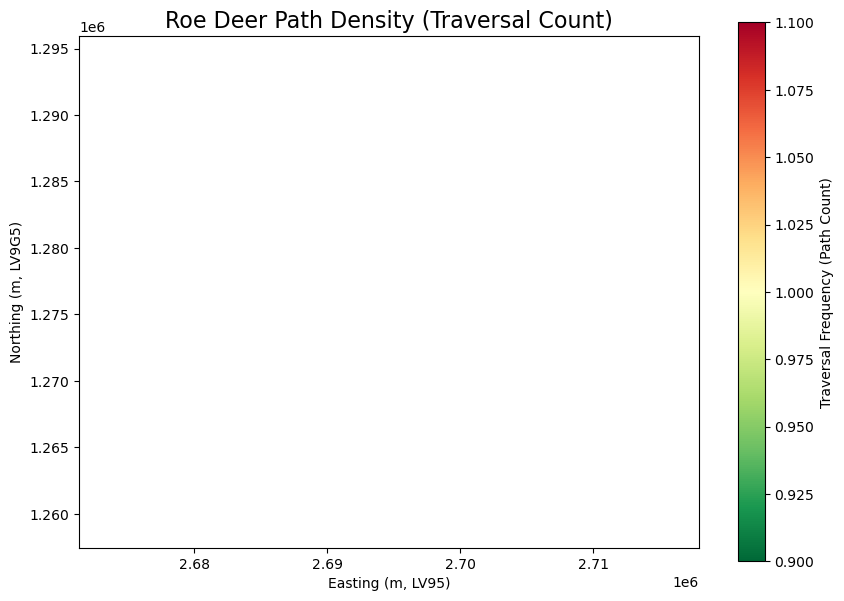

In [9]:
# --- Example Usage ---
TRAVERSAL_MAP_PATH = "C:/ZHAW/5.Semester/PA2/PA2-Modelling_Wildlife_Corridors/Results/traversal_count_map.tif"

plot_traversal_map(
    raster_path=TRAVERSAL_MAP_PATH,
    title='Roe Deer Path Density (Traversal Count)'
)